# Forecast Characteristics -- Section 10 only (accuracy/bias per hour)

Extract of `forecast_characteristics.ipynb` Section 10, re-run against the retrain
campaign completed 2026-08-24 (seeding-bug fix -- `np.random.seed(cfg.seed)` was
missing from `train_one_config`; batch_size 8->64, max_epochs 20->200, patience 5->10,
matching the original baseline forecaster's own convention; 1-stage dual-price's
epigraph dropped for training since it's provably inert for the decision -- see
`7_model_training/dfl_train_utils.py`). The full nine-section notebook (fan charts, band
overlays, seasonal averages, mean-median gap, solar-bias mediation) is archived at
`Z_archive/pre_final_train/forecast_characteristics.ipynb` -- only Section 10's own
setup is reproduced here (season indices, `plot_grid`, seed-averaging helpers), not the
other sections' fan-chart/band/solar machinery, which Section 10 never calls.

Two genuinely different per-hour metrics:
- **10a/10b** -- single-checkpoint (default seed 20240801) accuracy (MAE), seasonal 2x2
  grid plus a full-year overall graph, one market at a time.
- **10c/10d** -- all three retrained families (CRPS-only control, DFL single-price, DFL
  dual-price) against baseline, seed-averaged (N=5, mean +/- std shaded), three
  side-by-side panels sharing one y-axis per row so magnitudes are directly comparable
  across panels. 10c is MAE (`mean(|realised-mean|)`, always positive, "how wrong");
  10d is signed bias (`mean(mean-realised)`, "which direction, and by how much on
  average" -- not the same thing, per Jensen's inequality a forecaster can shift on one
  without shifting equally on the other.

## Setup

In [1]:
from __future__ import annotations
import sys
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR, QUANTILE_LEVELS, FrozenCopulaSampler,
)

In [2]:
print("loading test windows...")
windows = load_test_windows()

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id: str):
    dfl_ckpt = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, dfl_ckpt)


print(f"n_test_days={len(windows.delivery_start)}")

loading test windows...
[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)
n_test_days=366


In [3]:
cop_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop_bundle["Z_corr"], cop_bundle["quantile_levels"])

In [4]:
SEASON_MONTHS = {"spring": [3, 4, 5], "summer": [6, 7, 8], "autumn": [9, 10, 11], "winter": [12, 1, 2]}
SEASON_ORDER = ["spring", "summer", "autumn", "winter"]   # chronological through the test year

SEASON_DAY_INDICES = {}
_n_days = len(windows.delivery_start)
_months = np.array([windows.delivery_start[d].month for d in range(_n_days)])
for season, mo_list in SEASON_MONTHS.items():
    SEASON_DAY_INDICES[season] = np.where(np.isin(_months, mo_list))[0]
    print(f"{season:8s}: {len(SEASON_DAY_INDICES[season])} days")

ALL_DAYS = range(_n_days)

spring  : 92 days
summer  : 92 days
autumn  : 91 days
winter  : 91 days


In [5]:
dfl_single = load_dfl("dfl_1stage_single-price")
dfl_dual_balanced = load_dfl("dfl_1stage_dual-price")
single_mm_colors = {"baseline": "C0", "DFL single-price": "C1"}
dual_mae_colors = {"baseline": "C0", "DFL dual-price": "C3"}
comparison_mae_colors = {"baseline": "C0", "CRPS-only control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}

In [6]:
def plot_grid(plot_fn, cells, nrows, ncols, suptitle, colors, figsize=None):
    """cells: list of (title, forecaster_data) -- forecaster_data as required by
    plot_fn. One shared legend at the bottom, same pattern as plot_band_grid."""
    if figsize is None:
        figsize = (5.5 * ncols, 4.0 * nrows + 1)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)
    handles = labels = None
    for ax, (title, forecaster_data) in zip(axes.flat, cells):
        plot_fn(ax, forecaster_data, colors, title=title)
        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.suptitle(suptitle, fontsize=13)
    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6), fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()

In [7]:
SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]


def seed_variant(base_id: str, seed: int) -> str:
    return base_id if seed == 20240801 else f"{base_id}_seed{seed}"

## Section 10 -- accuracy per hour (MAE), baseline vs DFL

`mean(|realised - mean|)` -- average the ABSOLUTE error per day, THEN average across
days -- not `|mean(realised) - mean(mean)|` (average first, then take the absolute
value). By Jensen's inequality `mean(|e|) >= |mean(e)|` always, so this MAE is a genuine
typical-error magnitude (won't hide same-day cancellation the way a bias-style abs_err
can) -- appropriate for an "accuracy" question specifically, as opposed to a "systematic
bias" one.

For each market (single-price, dual-price): a seasonal 2x2 grid (baseline vs that
market's DFL, per season) plus one standalone graph with both lines over the FULL test
year (not per season) -- baseline's overall MAE is computed once and shared between both
markets' overall graphs.

In [ ]:
def hourly_mae(model, day_indices):
    """Mean ABSOLUTE ERROR by hour-of-day: |realised - mean| computed per day, then
    averaged across days -- see Section 10's markdown for why this differs from the
    bias-style abs_err columns elsewhere in the full notebook."""
    errs = []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(np.abs(realised - mean))
    return np.mean(errs, axis=0)   # (24,)


def plot_accuracy_by_hour(ax, forecaster_data, colors, title=""):
    """forecaster_data: {label: mae (24,) array}."""
    for label, mae in forecaster_data.items():
        ax.plot(np.arange(len(mae)), mae, "-o", color=colors[label], markersize=3,
                 label=label, linewidth=1.6)
    ax.set_xlabel("hour")
    ax.set_ylabel("MAE (MW)")
    if title:
        ax.set_title(title, fontsize=10)


def metric_across_seeds(metric_fn, base_id, day_indices=None):
    """metric_fn: hourly_mae or hourly_bias_own. Loads all 5 seeds of base_id,
    applies metric_fn to each, returns (mean_by_hour (24,), std_by_hour (24,)) across
    the 5 seeds -- the multi-seed analogue of Section 10c/10d's single-checkpoint
    lines."""
    days = ALL_DAYS if day_indices is None else day_indices
    vals = np.array([metric_fn(load_dfl(seed_variant(base_id, seed)), days) for seed in SEEDS])
    return vals.mean(axis=0), vals.std(axis=0)


mae_base_overall = hourly_mae(baseline_model, ALL_DAYS)
print("overall baseline MAE by hour computed (shared by 10a/10b's overall graphs)")

overall baseline MAE by hour computed (shared by 10a/10b's overall graphs)


### 10a -- single-price

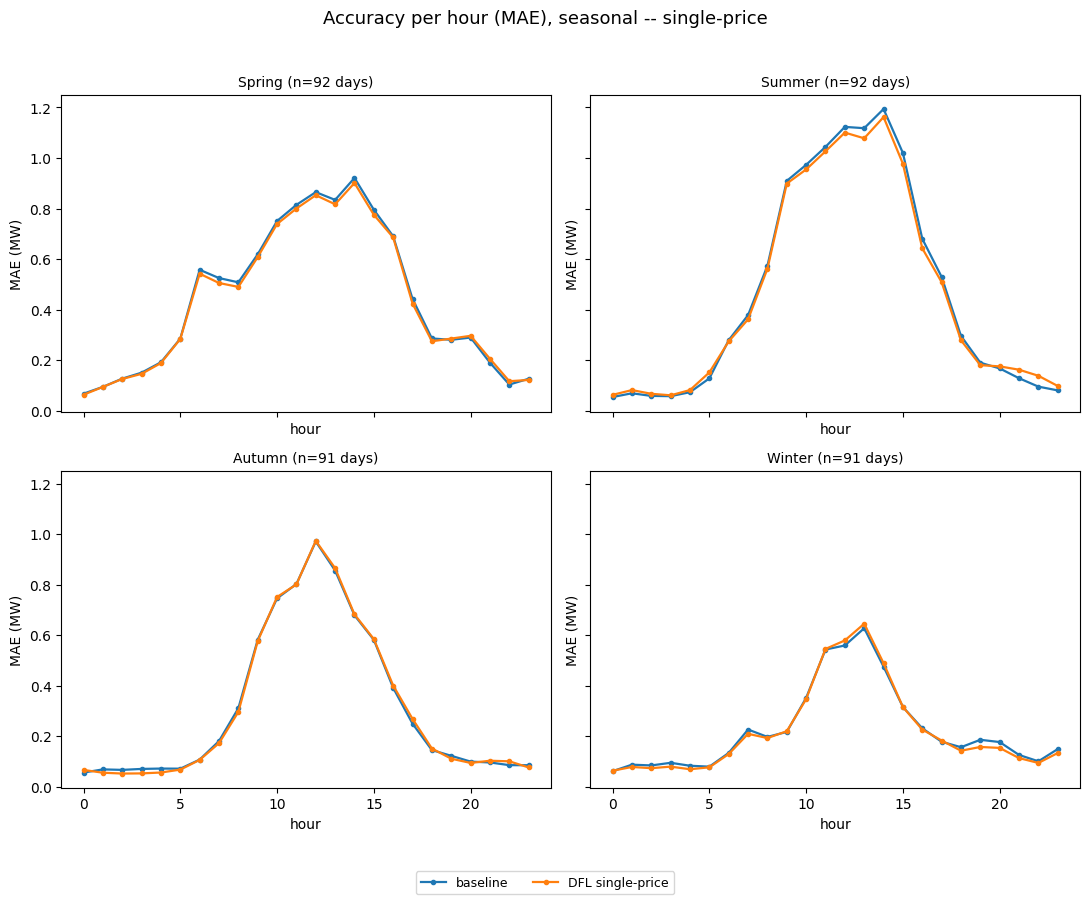

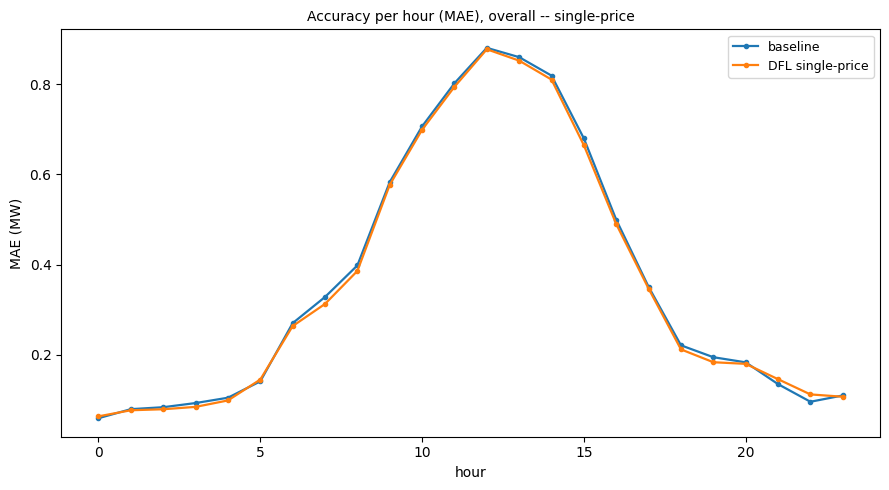

In [9]:
single_mae_cells = []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mae_base_s = hourly_mae(baseline_model, SEASON_DAY_INDICES[season])
    mae_dfl_s = hourly_mae(dfl_single, SEASON_DAY_INDICES[season])
    data = {"baseline": mae_base_s, "DFL single-price": mae_dfl_s}
    single_mae_cells.append((f"{season.capitalize()} (n={n_days} days)", data))

plot_grid(plot_accuracy_by_hour, single_mae_cells, nrows=2, ncols=2,
          suptitle="Accuracy per hour (MAE), seasonal -- single-price", colors=single_mm_colors)

mae_single_overall = hourly_mae(dfl_single, ALL_DAYS)
fig, ax = plt.subplots(figsize=(9, 5))
plot_accuracy_by_hour(ax, {"baseline": mae_base_overall, "DFL single-price": mae_single_overall},
                       single_mm_colors, title="Accuracy per hour (MAE), overall -- single-price")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 10b -- dual-price

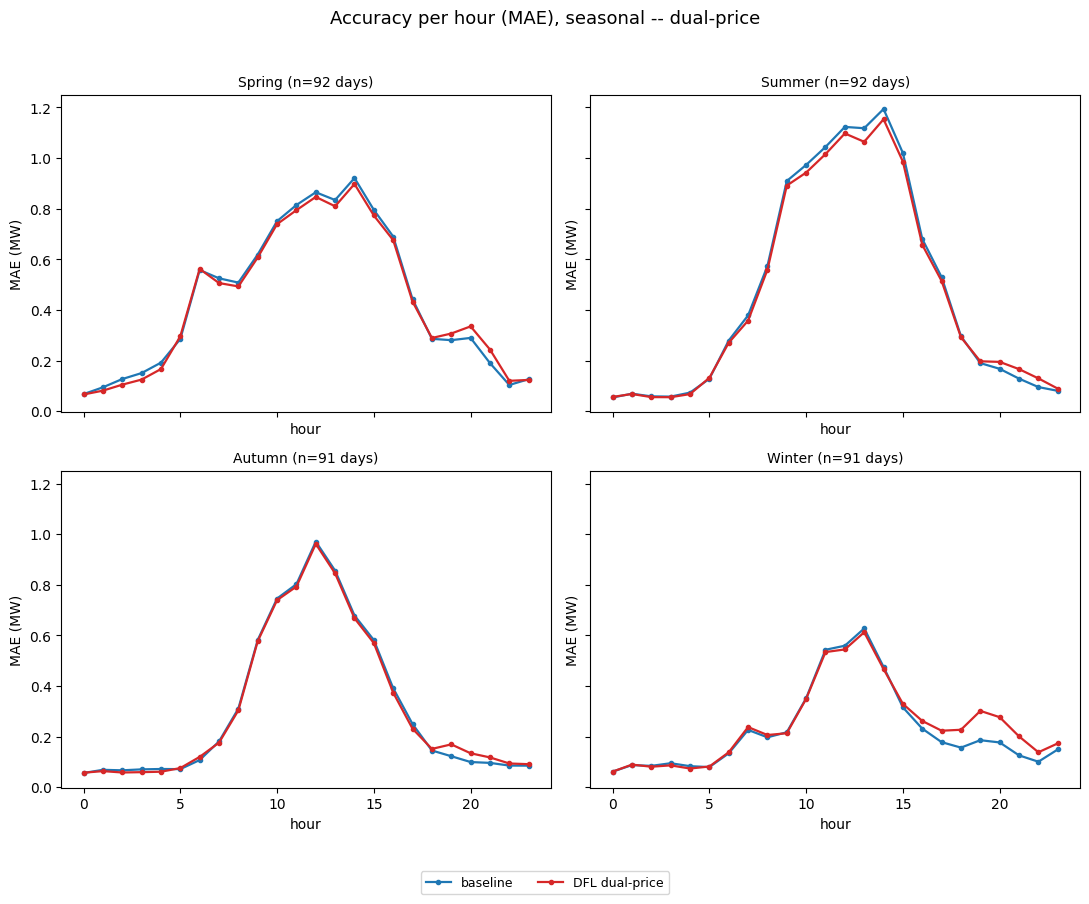

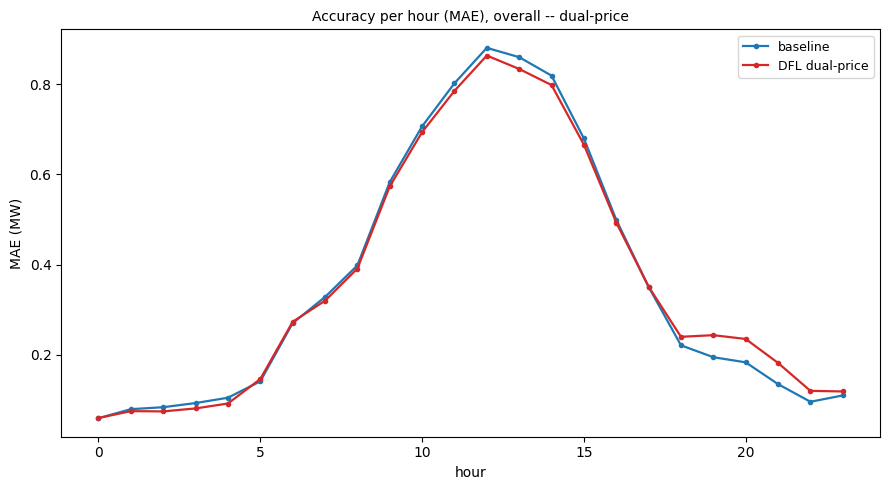

In [10]:
dual_mae_cells = []
for season in SEASON_ORDER:
    n_days = len(SEASON_DAY_INDICES[season])
    mae_base_s = hourly_mae(baseline_model, SEASON_DAY_INDICES[season])
    mae_dfl_s = hourly_mae(dfl_dual_balanced, SEASON_DAY_INDICES[season])
    data = {"baseline": mae_base_s, "DFL dual-price": mae_dfl_s}
    dual_mae_cells.append((f"{season.capitalize()} (n={n_days} days)", data))

plot_grid(plot_accuracy_by_hour, dual_mae_cells, nrows=2, ncols=2,
          suptitle="Accuracy per hour (MAE), seasonal -- dual-price", colors=dual_mae_colors)

mae_dual_overall = hourly_mae(dfl_dual_balanced, ALL_DAYS)
fig, ax = plt.subplots(figsize=(9, 5))
plot_accuracy_by_hour(ax, {"baseline": mae_base_overall, "DFL dual-price": mae_dual_overall},
                       dual_mae_colors, title="Accuracy per hour (MAE), overall -- dual-price")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 10c -- complete comparison, one row per forecaster (baseline vs each retrained model)

5-seed mean +/- std, split into three side-by-side panels -- baseline vs CRPS-only
control, baseline vs DFL single-price, baseline vs DFL dual-price -- rather than four
series overlaid on one axis. All three panels in the row share the same y-axis (so a
wide band in one panel is directly comparable to a narrow one in another) and carry the
same horizontal reference gridlines, making cross-panel magnitude comparison possible
without re-reading each axis. This is the direct visual analogue of Q1's
`pct_change_min`/`pct_change_max` columns in `aggregate_results.ipynb`.

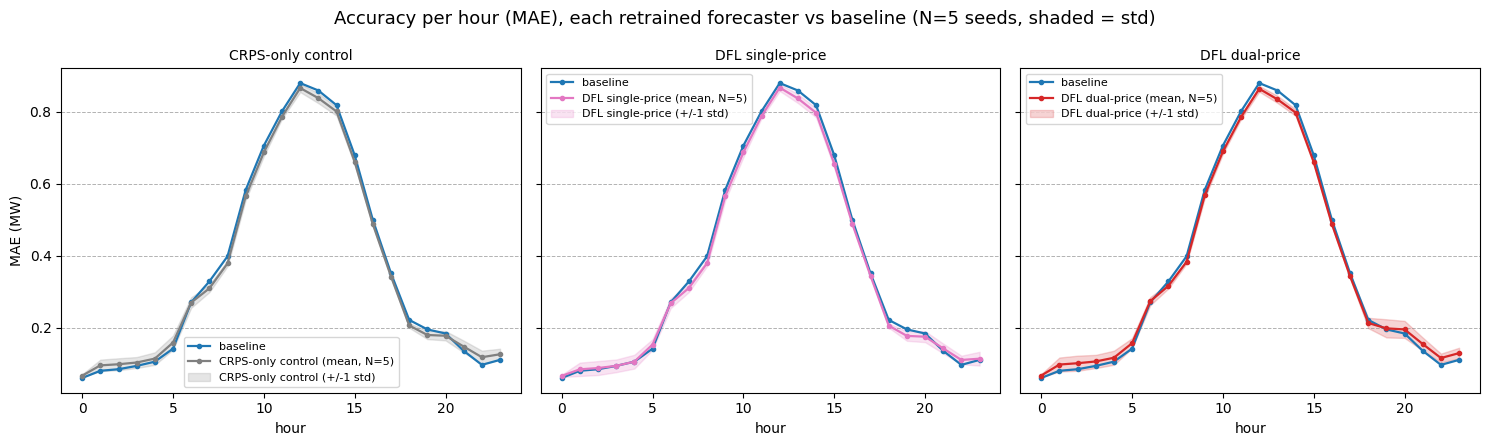

In [11]:
def plot_metric_row(baseline_series, panels, colors, ylabel, fig_title, zero_line=False):
    """One row of len(panels) subplots, sharing the y-axis, each comparing the fixed
    baseline_series (24,) against one seed-averaged forecaster.
    panels: list of (label, mean (24,), std (24,)) tuples, one per subplot.
    Horizontal gridlines (shared across the row via sharey) make magnitudes directly
    comparable panel-to-panel, not just within a single panel."""
    h = np.arange(24)
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5), sharey=True)
    for ax, (label, mean, std) in zip(axes, panels):
        ax.plot(h, baseline_series, "-o", color=colors["baseline"], markersize=3,
                 label="baseline", linewidth=1.6)
        ax.plot(h, mean, "-o", color=colors[label], markersize=3,
                 label=f"{label} (mean, N=5)", linewidth=1.6)
        ax.fill_between(h, mean - std, mean + std, color=colors[label], alpha=0.2,
                          label=f"{label} (+/-1 std)")
        if zero_line:
            ax.axhline(0, color="black", linewidth=0.9, zorder=2)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, color="grey", alpha=0.6, zorder=0)
        ax.set_xlabel("hour")
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8, loc="best")
    axes[0].set_ylabel(ylabel)
    fig.suptitle(fig_title, fontsize=13)
    fig.tight_layout()
    return fig, axes


mae_crps_only_mean, mae_crps_only_std = metric_across_seeds(hourly_mae, "crps_only_retrained")
mae_single_mean, mae_single_std = metric_across_seeds(hourly_mae, "dfl_1stage_single-price")
mae_dual_mean, mae_dual_std = metric_across_seeds(hourly_mae, "dfl_1stage_dual-price")

fig, axes = plot_metric_row(
    mae_base_overall,
    [("CRPS-only control", mae_crps_only_mean, mae_crps_only_std),
     ("DFL single-price", mae_single_mean, mae_single_std),
     ("DFL dual-price", mae_dual_mean, mae_dual_std)],
    comparison_mae_colors, ylabel="MAE (MW)",
    fig_title="Accuracy per hour (MAE), each retrained forecaster vs baseline (N=5 seeds, shaded = std)")
plt.show()

### 10d -- forecast bias per hour (signed), same layout as 10c

Companion to 10c, not a replacement: MAE (10c) is `mean(|realised - mean|)` -- always
positive, tells you HOW WRONG each forecaster is at each hour but not which direction.
This is `mean(mean - realised)` -- SIGNED, each forecaster's own systematic bias (not a
delta between forecasters, and not absolute-valued) -- **positive means over-predicting**
on average at that hour (forecast too high), **negative means under-predicting** (forecast
too low). Worth checking directly against 10c's observation: a forecaster can be MORE
biased at an hour while still being more (or less) accurate there overall, if its
variance/spread also changed -- bias and MAE aren't forced to move together.

Same three-panel, shared-y-axis, gridlined layout as 10c, plus a solid zero line (the
natural reference for a signed quantity) on every panel.

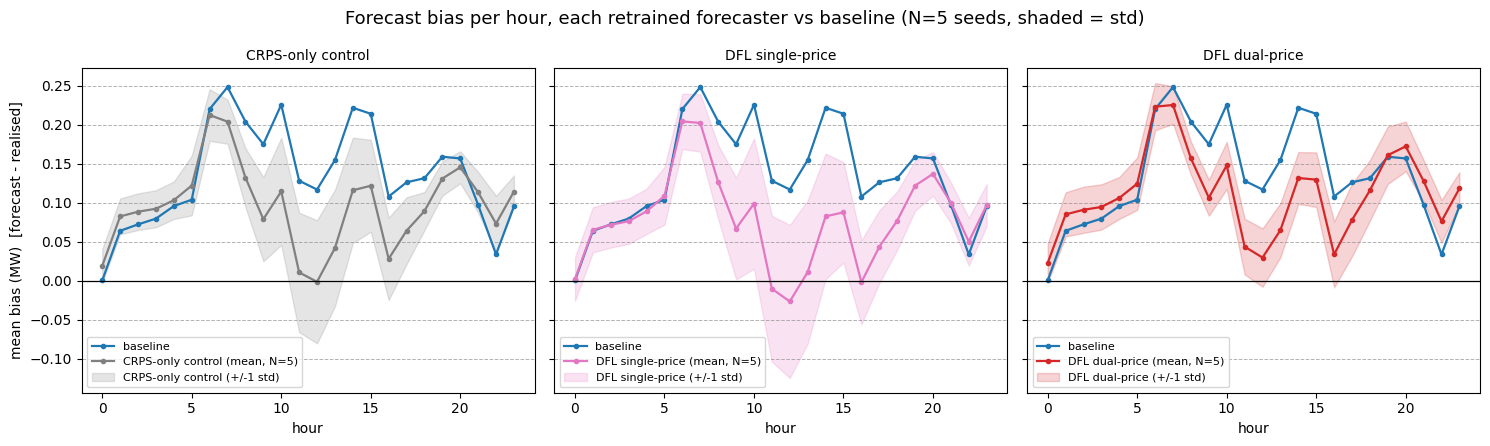

: 

In [ ]:
def hourly_bias_own(model, day_indices):
    """Mean SIGNED error by hour-of-day: (mean - realised) computed per day, then
    averaged across days -- each forecaster's own bias, not a delta between forecasters
    and not absolute-valued (contrast with hourly_mae). Positive = forecaster predicts
    too much (over-predicts), negative = forecaster predicts too little (under-predicts)."""
    errs = []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(mean - realised)
    return np.mean(errs, axis=0)   # (24,)


bias_base_overall = hourly_bias_own(baseline_model, ALL_DAYS)
bias_crps_only_mean, bias_crps_only_std = metric_across_seeds(hourly_bias_own, "crps_only_retrained")
bias_single_mean, bias_single_std = metric_across_seeds(hourly_bias_own, "dfl_1stage_single-price")
bias_dual_mean, bias_dual_std = metric_across_seeds(hourly_bias_own, "dfl_1stage_dual-price")

fig, axes = plot_metric_row(
    bias_base_overall,
    [("CRPS-only control", bias_crps_only_mean, bias_crps_only_std),
     ("DFL single-price", bias_single_mean, bias_single_std),
     ("DFL dual-price", bias_dual_mean, bias_dual_std)],
    comparison_mae_colors, ylabel="mean bias (MW)  [forecast - realised]",
    fig_title="Forecast bias per hour, each retrained forecaster vs baseline (N=5 seeds, shaded = std)",
    zero_line=True)
plt.show()